<a href="https://colab.research.google.com/github/ArjunBhakta/Data-Science-Cohort-20/blob/main/Project_2_Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction Brief


The project should be done using Regression prediction techniques ( with feature scaling and regularization ) as covered in class.
The goal is to minimize the RMS ***percentage*** error ( root mean squared percentage error - RMSPE ) on your prediction of the house sales price.



Any of the available features can be used in the regression, but a minimum set of variables that do the job should be the ultimate goal.



A data dictionary file is available at AWS S3 at [Housing Data Dictionary]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf ).



The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv .


## Package Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math
import scipy.stats as stats
import plotly.express as px

## Data Collection

In [2]:
df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv')

In [3]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


<Axes: >

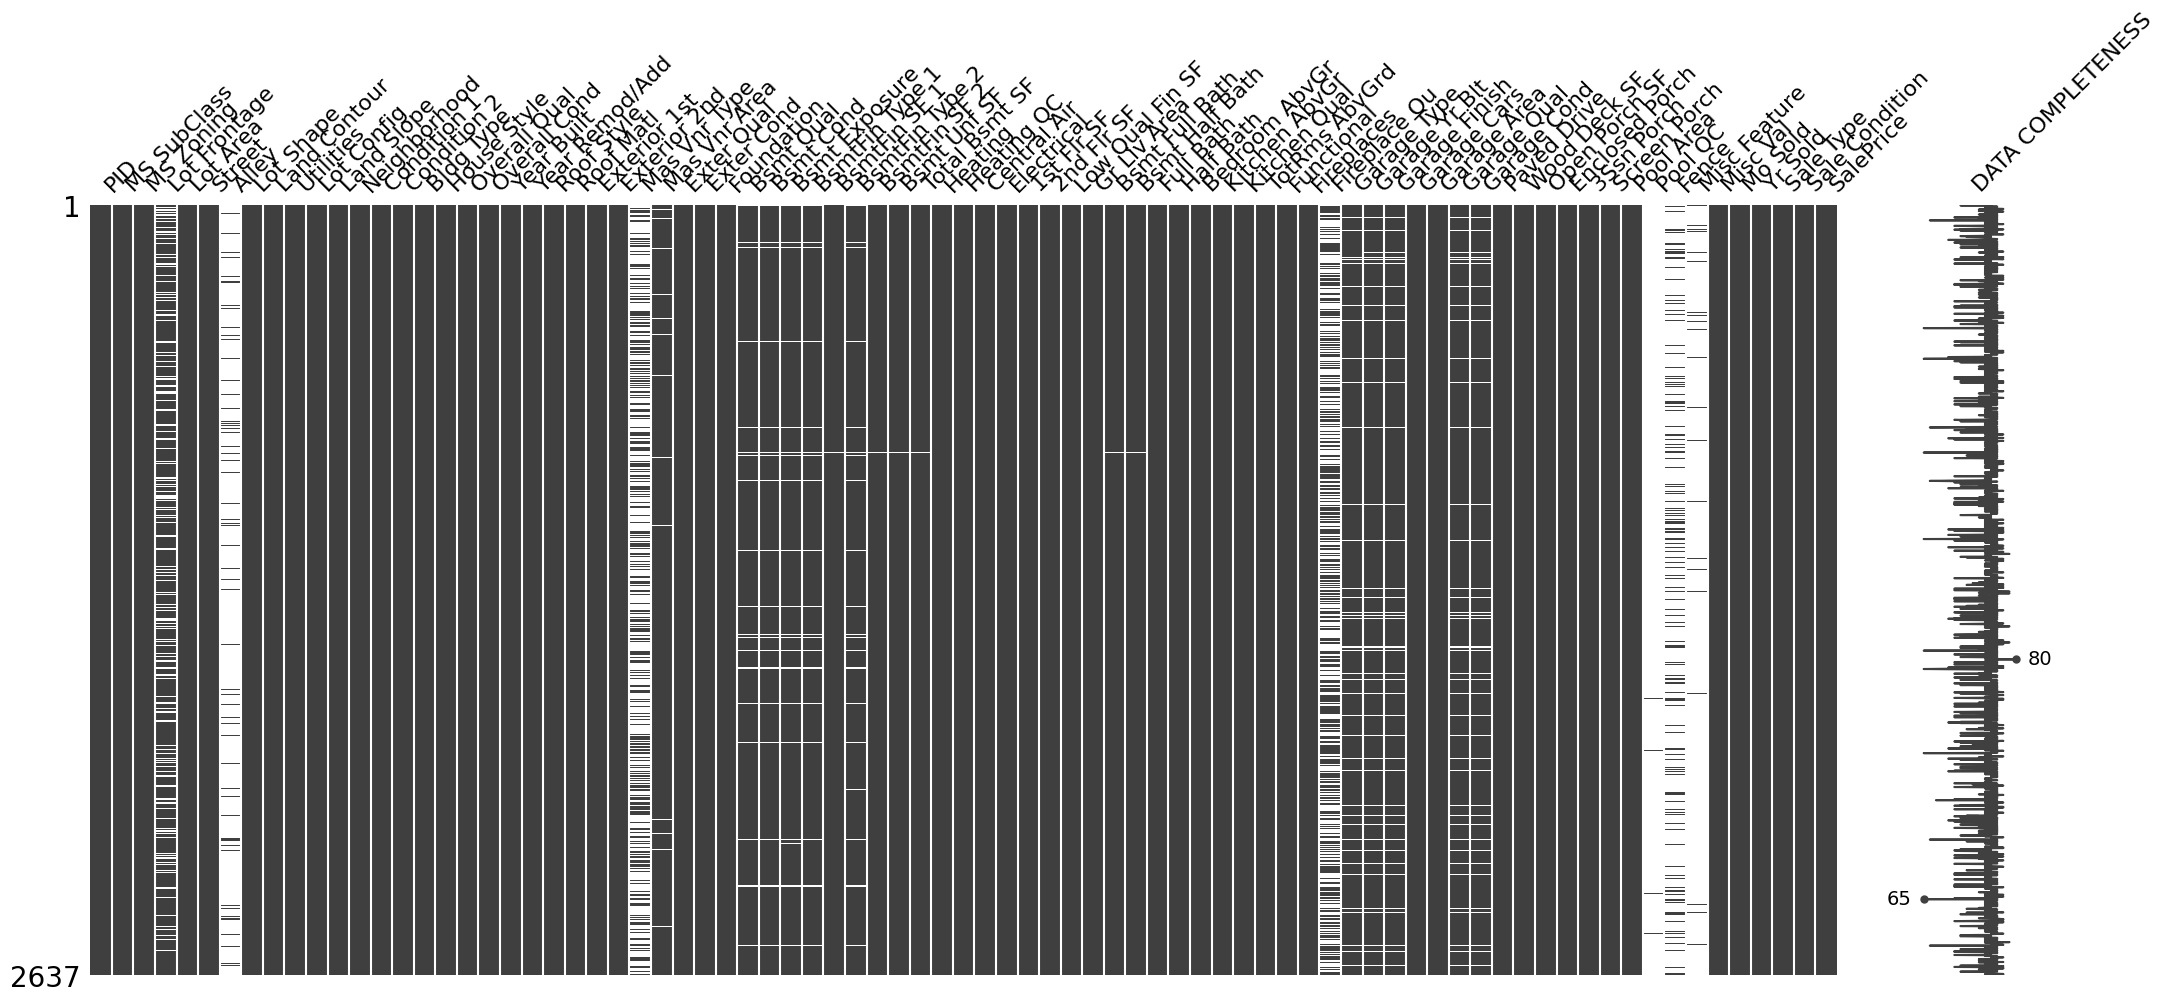

In [4]:
# Plot the missing values in the Data Set
msno.matrix(df, labels=True)

## Initial Data Analysis
When comparing the Data Dictionary with Data Set  a few discrepencies were found reported below with approach on how to handle


### Discrepancy 1 — Dataset Shape

| | Rows | Columns |
|---|---|---|
| Documentation | 2,930 | 82 |
| Actual data | 2,637 | 81 |
| Difference | **−293 (10%)** | **−1** |

> **CRITICAL** — The dataset is missing 10% of documented observations and one column (see Discrepancy 2).

### Discrepancy 2 — Missing Column: "Order"

| | Value |
|---|---|
| Documentation | First column is `Order` (Discrete) — observation number |
| Actual data | `Order` is **not present**; first column is `PID` |

> **LOW** — The index column was dropped before delivery. Not needed for modeling — `PID` serves as the row identifier.

### Discrepancy 3 — Column Names Differ from Documentation

| | Doc Name | Actual Name | Change |
|---|---|---|---|
| 1 | Exterior 1 | Exterior 1st | Suffix changed |
| 2 | Exterior 2 | Exterior 2nd | Suffix changed |
| 3 | HeatingQC | Heating QC | Space inserted |
| 4 | BsmtFinType 2 | BsmtFin Type 2 | Spacing changed |
| 5 | Bedroom | Bedroom AbvGr | Qualifier added |
| 6 | Kitchen | Kitchen AbvGr | Qualifier added |
| 7 | KitchenQual | Kitchen Qual | Space inserted |
| 8 | TotRmsAbvGrd | TotRms AbvGrd | Space inserted |
| 9 | FireplaceQu | Fireplace Qu | Space inserted |
| 10 | 3-Ssn Porch | 3Ssn Porch | Hyphen removed |

> **MEDIUM** — Use actual column names in all code. Documentation names will cause `KeyError`.

### Discrepancy 4 — Categorical Values Differ from Documentation

| # | Column | Doc Value | Actual Value | Notes |
|---|---|---|---|---|
| 1 | `MS Zoning` | `A`, `C`, `I` | `A (agr)`, `C (all)`, `I (all)` | Suffix added in parentheses |
| 2 | `MS Zoning` | `RP` | *(not present)* | Residential Low Density Park missing from data |
| 3 | `Bldg Type` | `TwnhsI` | `Twnhs` | Renamed |
| 4 | `Bldg Type` | `2FmCon` | `2fmCon` | Capital F → lowercase f |
| 5 | `Neighborhood` | `Names` | `NAmes` | Doc typo — data uses `NAmes` (North Ames) |
| 6 | `Exterior 2nd` | `BrkComm` | `Brk Cmn` | Abbreviation differs from `Exterior 1st` |
| 7 | `Exterior 2nd` | `CemntBd` | `CmentBd` | Spelling differs from `Exterior 1st` |
| 8 | `Mas Vnr Type` | `None` | `NaN` | "None" encoded as null, not string |
| 9 | `Sale Type` | `WD` | `WD ` (trailing space) | Needs `.str.strip()` |
| 10 | `Exterior 1st` | `Other` | *(not present)* | Doc lists value with no matching rows |

> **HIGH** — These mismatches will cause silent errors in encoding if not corrected first.

### Discrepancy 5 — Data Type Mismatches

| Column | Doc Type | Actual dtype | Notes |
|---|---|---|---|
| `MS SubClass` | Nominal (categorical) | `int64` | Codes like 020, 060 — must be cast to string before encoding |
| `Garage Cars` | Discrete (int) | `float64` | Float due to 1 null row |
| `Garage Area` | Continuous | `float64` | Float due to 1 null row |
| `Bsmt Full Bath` | Discrete (int) | `float64` | Float due to 2 null rows |
| `Bsmt Half Bath` | Discrete (int) | `float64` | Float due to 2 null rows |
| `BsmtFin SF 1` | Continuous | `float64` | Float due to 1 null row |
| `BsmtFin SF 2` | Continuous | `float64` | Float due to 1 null row |
| `Bsmt Unf SF` | Continuous | `float64` | Float due to 1 null row |
| `Total Bsmt SF` | Continuous | `float64` | Float due to 1 null row |

> **MEDIUM** — `MS SubClass` must be cast to `str` before encoding. All other float columns are safe to cast to `int` after null imputation.

### Discrepancy 6 — Numeric Range: Overall Cond

| | Value |
|---|---|
| Documentation | Scale 1–10 (10 = Very Excellent) |
| Actual max | **9** — no observations rated 10 |

> **LOW** — The top rating simply has no observations in this sample. No action required.

### Discrepancy 7 — "NA" Category Values Encoded as NaN

The documentation lists `NA` as a valid category for 15 columns, meaning the feature physically does not exist on that property. Pandas read these as `NaN` (null), making them appear as missing data.

| Column | Null Count | Null % | Meaning |
|---|---|---|---|
| `Pool QC` | 2,626 | 99.6% | No pool |
| `Misc Feature` | 2,541 | 96.4% | None |
| `Alley` | 2,457 | 93.2% | No alley access |
| `Fence` | 2,109 | 80.0% | No fence |
| `Mas Vnr Type` | 1,607 | 60.9% | None |
| `Fireplace Qu` | 1,284 | 48.7% | No fireplace |
| `Garage Type` | 145 | 5.5% | No garage |
| `Garage Finish` | 147 | 5.6% | No garage |
| `Garage Qual` | 147 | 5.6% | No garage |
| `Garage Cond` | 147 | 5.6% | No garage |
| `BsmtFin Type 2` | 74 | 2.8% | No basement |
| `Bsmt Qual` | 73 | 2.8% | No basement |
| `Bsmt Cond` | 73 | 2.8% | No basement |
| `BsmtFin Type 1` | 73 | 2.8% | No basement |
| `Bsmt Exposure` | 76 | 2.9% | No basement |

> **HIGH** — These are **not** missing data. They must be imputed with the string `'None'`, not dropped or median-filled.

### IDA — Discrepancy Summary

| ID | Issue | Severity | Action Required |
|---|---|---|---|
| #1 | Dataset shape | **CRITICAL** | 2,637 rows (not 2,930); 81 cols (not 82) |
| #2 | Missing column | LOW | `Order` absent — not needed for modeling |
| #3 | Column name changes | MEDIUM | 10 columns renamed — use actual names in code |
| #4 | Categorical value diffs | **HIGH** | 10 value mismatches — fix before encoding |
| #5 | dtype mismatches | MEDIUM | `MS SubClass` must be categorical; others are float due to nulls |
| #6 | Numeric range | LOW | `Overall Cond` max is 9, not 10 |
| #7 | NA-as-NaN encoding | **HIGH** | 15 columns use NaN to mean "feature absent" — impute with `'None'` |

## Data Cleaning *(Regression-Focused)*
Handle missing values, fix data types, remove irrelevant columns, and encode categorical variables in preparation for regression modeling. Address the issues discovered in IDA documented above

Notebook organization :

- View Missing Values
- Step 1 - Impute None based on Discrepency #7
- Step 2 - Handle remaining Nulls
- Step 3 - MS Sub Class - fix datatype
- Step 4 - Strip white space in str columns
- Step 5 - Ordinal Columns Encoding
- Step 6 - Nominal Columns - one hot encoding  

#### View Missing Values

In [5]:
# Missing value Count
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing

Columns with missing values: 26


,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Cond,147
Garage Yr Blt,147
Garage Finish,147


#### Step 1 (Address Discrepancy #7)
These columns use NaN to mean "feature does not exist", NOT missing data.
Replacing with the string 'None' preserves meaning and prevents bad imputation.

In [6]:
# ── STEP 1: Impute structural NaNs (Discrepancy #7) ───────────────────────────
# These columns use NaN to mean "feature does not exist", NOT missing data.
# Replacing with the string 'None' preserves meaning and prevents bad imputation.

na_as_none_cols = [
    'Alley',           # No alley access
    'Bsmt Qual',       # No basement
    'Bsmt Cond',       # No basement
    'Bsmt Exposure',   # No basement
    'BsmtFin Type 1',  # No basement
    'BsmtFin Type 2',  # No basement
    'Fireplace Qu',    # No fireplace
    'Garage Type',     # No garage
    'Garage Finish',   # No garage
    'Garage Qual',     # No garage
    'Garage Cond',     # No garage
    'Pool QC',         # No pool
    'Fence',           # No fence
    'Misc Feature',    # None
    'Mas Vnr Type',    # None (no masonry veneer)
]

df[na_as_none_cols] = df[na_as_none_cols].fillna('None')

# Verify — all 15 columns should now have 0 nulls
remaining = df[na_as_none_cols].isnull().sum()
print(f"Null counts after imputation:\n{remaining.to_string()}")

Null counts after imputation:
Alley             0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
Fireplace Qu      0
Garage Type       0
Garage Finish     0
Garage Qual       0
Garage Cond       0
Pool QC           0
Fence             0
Misc Feature      0
Mas Vnr Type      0


<Axes: >

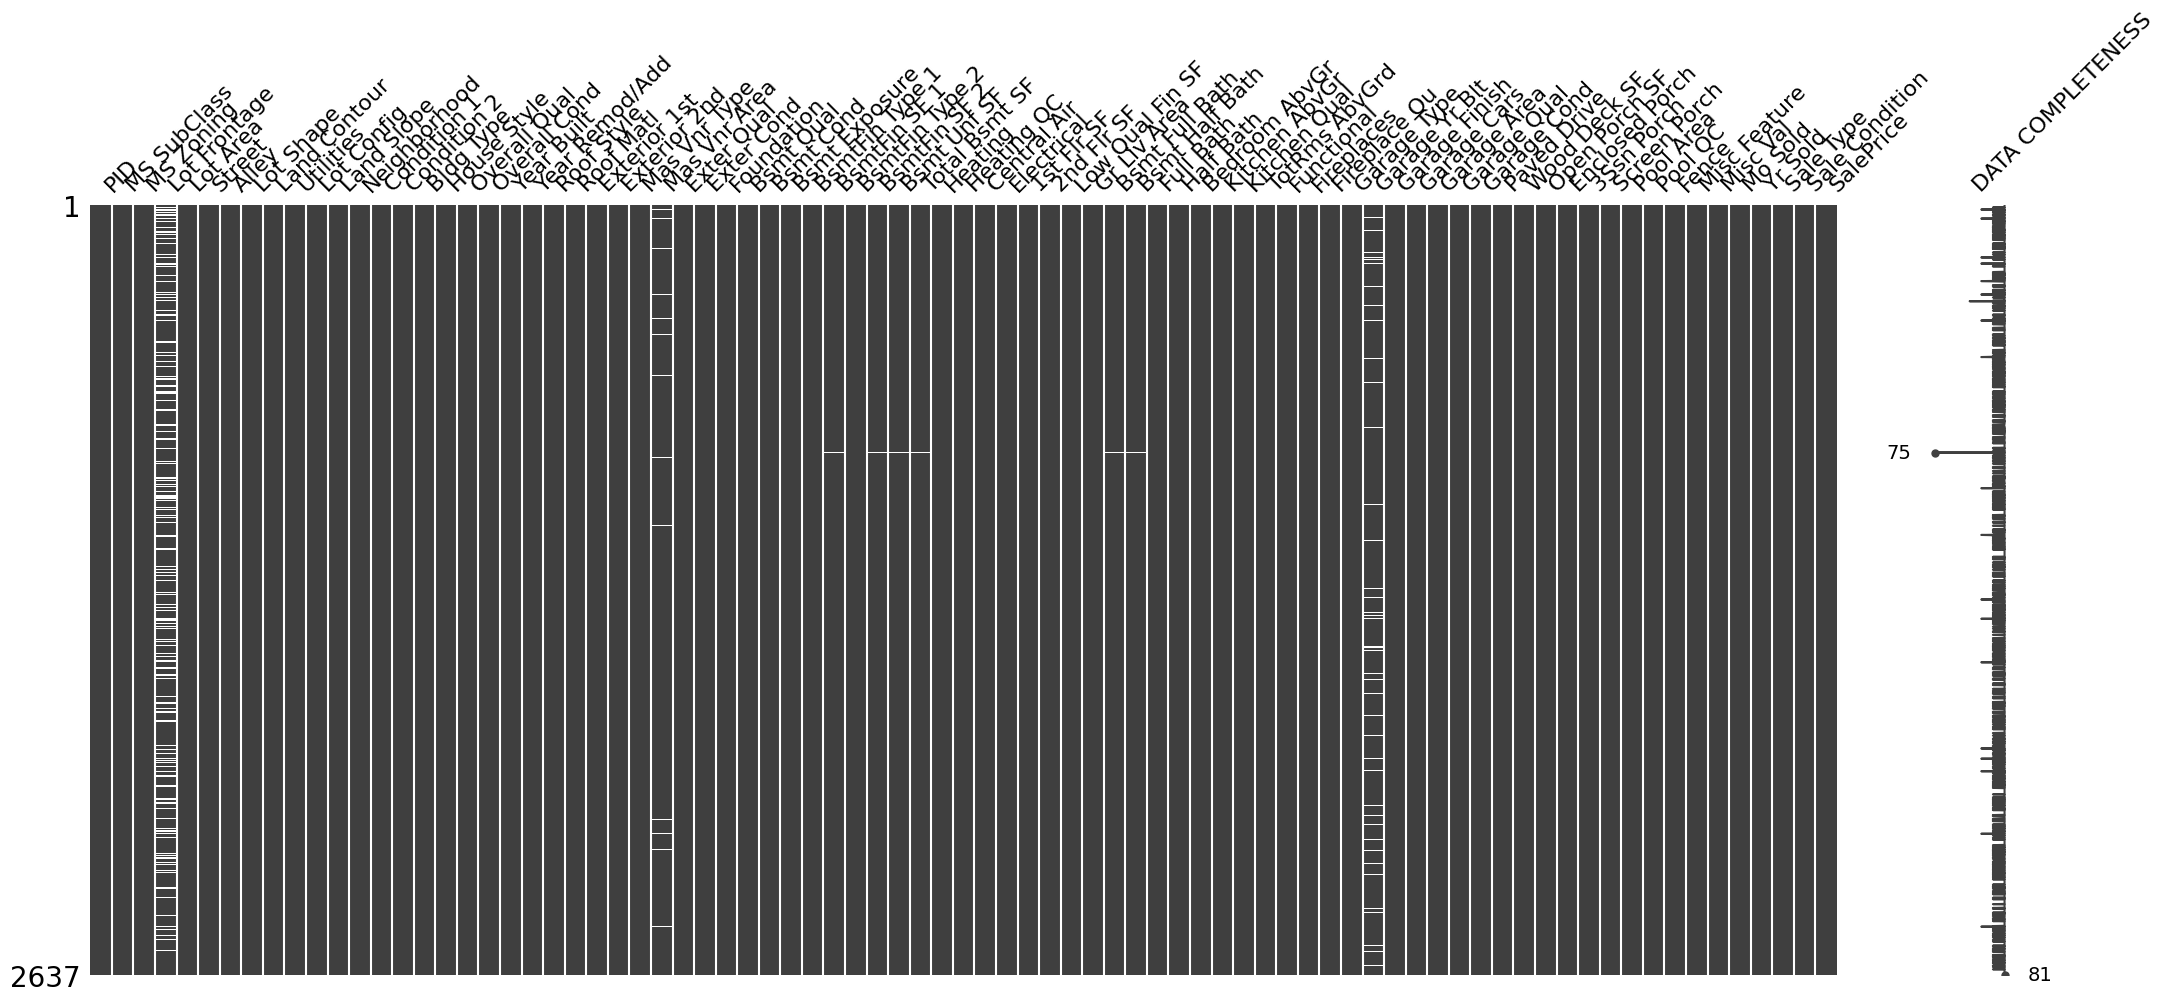

In [7]:
# Plot the missing values in the Data Set after
msno.matrix(df, labels=True)

In [8]:
# Missing value Count
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing

Columns with missing values: 11


,0
Lot Frontage,449
Garage Yr Blt,147
Mas Vnr Area,23
Bsmt Half Bath,2
Bsmt Full Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Total Bsmt SF,1
Bsmt Unf SF,1
Garage Cars,1


#### STEP 2 — Remaining Numeric Nulls Strategy

| Column | Nulls | % | Strategy | Reason |
|---|---|---|---|---|
| `Lot Frontage` | 449 | 17.0% | **Drop column** | Too many missing values to impute reliably |
| `Garage Yr Blt` | 147 | 5.6% | **Drop column** | Year built not meaningful for regression; too many gaps |
| `Mas Vnr Area` | 23 | 0.9% | Fill `0` | Missing area = no veneer recorded |
| `Bsmt Full Bath` | 2 | 0.1% | Fill `0` | Basement exists but no bathroom count → 0 |
| `Bsmt Half Bath` | 2 | 0.1% | Fill `0` | Same logic |
| `BsmtFin SF 1` | 1 | <0.1% | Fill `0` | Single data entry gap → 0 SF |
| `BsmtFin SF 2` | 1 | <0.1% | Fill `0` | Same |
| `Bsmt Unf SF` | 1 | <0.1% | Fill `0` | Same |
| `Total Bsmt SF` | 1 | <0.1% | Fill `0` | Same |
| `Garage Cars` | 1 | <0.1% | Fill `0` | Single data entry gap → 0 |
| `Garage Area` | 1 | <0.1% | Fill `0` | Same |

In [9]:
# Drop columns with too many missing values
df.drop(columns=['Lot Frontage', 'Garage Yr Blt'], inplace=True)

In [10]:
# Drop identifier — not a feature
df.drop(columns=['PID'], inplace=True)

In [11]:
# Zero-fill small data entry gaps
zero_fill_cols = [
    'Mas Vnr Area',
    'Bsmt Full Bath', 'Bsmt Half Bath',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    'Garage Cars', 'Garage Area',
]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

In [12]:
df.isnull().sum()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Alley,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


#### Step 3 MS Subclass is being treated as int but is actually categorical- fix by casting to string

In [13]:
# MS SubClass: numeric codes that are actually nominal categories (20, 60, 120, etc.)
# Must be string before one-hot encoding so it isn't treated as a continuous number
df['MS SubClass'] = df['MS SubClass'].astype(str)

#### Step 4 - strip white space in str columns

In [14]:
# Sale Type has a trailing space on 'WD ' — strip all string columns to be safe
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print('Sale Type unique values after strip:')
print(sorted(df['Sale Type'].unique()))


Sale Type unique values after strip:
['COD', 'CWD', 'Con', 'ConLD', 'ConLI', 'ConLw', 'New', 'Oth', 'VWD', 'WD']


In [15]:

df_viz = df.copy()

#### Step 5 Oridinal Columns get order-based encoding

In [16]:
# ── STEP 5: Encode categorical variables ──────────────────────────────────────
# Ordinal cols → integer map (preserves meaningful order)
# Shared quality scale: None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_mappings = {
    # Quality / condition (5-point scale)
    'Exter Qual':     qual_map,
    'Exter Cond':     qual_map,
    'Bsmt Qual':      qual_map,
    'Bsmt Cond':      qual_map,
    'Heating QC':     qual_map,
    'Kitchen Qual':   qual_map,
    'Fireplace Qu':   qual_map,
    'Garage Qual':    qual_map,
    'Garage Cond':    qual_map,
    'Pool QC':        {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},

    # Basement finish type (7-point scale)
    'BsmtFin Type 1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFin Type 2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},

    # Basement exposure
    'Bsmt Exposure':  {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},

    # Garage finish
    'Garage Finish':  {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},

    # Fence quality
    'Fence':          {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},

    # Functional (8-point: Typ is best)
    'Functional':     {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},

    # Lot shape (regular is best)
    'Lot Shape':      {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},

    # Land slope
    'Land Slope':     {'Gtl': 1, 'Mod': 2, 'Sev': 3},

    # Paved driveway
    'Paved Drive':    {'N': 0, 'P': 1, 'Y': 2},

    # Utilities
    'Utilities':      {'ELO': 1, 'NoSeWa': 2, 'NoSewr': 3, 'AllPub': 4},
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)



#### Step 6 - Nominal columns - one-hot encode
This is required so that numerical relationships don't occur

In [17]:
# One-hot encode all remaining nominal (object) columns
# drop_first=True drops one dummy per column to avoid perfect multicollinearity
nominal_cols = df.select_dtypes('object').columns.tolist()
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [18]:
print(f'Shape after encoding: {df.shape}')
print(f'Remaining object columns: {df.select_dtypes("object").columns.tolist()}')
print(f'Dtypes: {df.dtypes.value_counts().to_dict()}')

Shape after encoding: (2637, 224)
Remaining object columns: []
Dtypes: {dtype('bool'): 170, dtype('int64'): 45, dtype('float64'): 9}


## EDA
- Step 1 Examine Target Variable
- Step 2 Check Correlations for Numerical Values
- Step 3 Anova Correlations
- Step 4 Other Exploratory Plots for Intuition Building

#### Step 1- Examine Target ( Sales Price )
Notes :
- Target has a Right- Skewed distribution
- Box plot shows outliers
- Consider Log transformation in Data Proccesing Steps

In [19]:
# 1. Create the histogram
fig = px.histogram(df, x="SalePrice", nbins=50, title="Distribution of SalePrice")
fig.show()

In [20]:
# --- Box plot ---
fig1 = px.box(
    df,
    y='SalePrice',
    title='SalePrice — Box Plot (outlier check)',
    labels={'y': 'SalePrice ($)'},
    color_discrete_sequence=['steelblue'],
    points='outliers',
)
fig1.show()

In [21]:
df['SalePrice'].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [22]:
#log transform data to be normally distributed
log_target = np.log1p(df['SalePrice'])
fig = px.histogram(log_target, x="SalePrice", nbins=50, title="Distribution of Log transformed SalePrice")
fig.show()

In [23]:
target = df['SalePrice']
log_target = np.log1p(df['SalePrice'])

print('='*50)
print('SalePrice — Summary Statistics')
print('='*50)
print(f'  Count:      {target.count():,}')
print(f'  Mean:       ${target.mean():,.0f}')
print(f'  Median:     ${target.median():,.0f}')
print(f'  Std Dev:    ${target.std():,.0f}')
print(f'  Min:        ${target.min():,.0f}')
print(f'  Max:        ${target.max():,.0f}')
print(f'  Skewness:   {target.skew():.3f}  (>1 = heavily right-skewed)')
print(f'  Kurtosis:   {target.kurtosis():.3f}')
print()
print('Log-transformed SalePrice:')
print(f'  Skewness:   {log_target.skew():.3f}  (closer to 0 = more normal)')
print(f'  Kurtosis:   {log_target.kurtosis():.3f}')
print()
print(f'Mean > Median by ${target.mean() - target.median():,.0f} — confirms right skew')


SalePrice — Summary Statistics
  Count:      2,637
  Mean:       $179,986
  Median:     $160,000
  Std Dev:    $78,309
  Min:        $12,789
  Max:        $745,000
  Skewness:   1.642  (>1 = heavily right-skewed)
  Kurtosis:   4.451

Log-transformed SalePrice:
  Skewness:   -0.074  (closer to 0 = more normal)
  Kurtosis:   1.615

Mean > Median by $19,986 — confirms right skew


#### Step 2 -  Check Correlations for Numerical Values

Notes:
- Plan to keep 15 features for intial test

In [24]:
# ── Correlation Bar Chart: Top 20 Features vs SalePrice ───────────────────────
corr = df.corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values()
top_n = 20
top_corr = pd.concat([corr.head(5), corr.tail(top_n - 5)]).sort_values()

In [25]:
fig = px.bar(
    x=top_corr.values,
    y=top_corr.index,
    orientation='h',
    color=top_corr.values,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title=f'Top {top_n} Feature Correlations with SalePrice',
    labels={'x': 'Pearson r', 'y': 'Feature'},
)
fig.update_layout(coloraxis_showscale=False, height=550)
fig.show()

In [26]:
# ── Correlation Heatmap: Top 20 Features + SalePrice ──────────────────────────
top20_cols = corr.tail(20).index.tolist() + ['SalePrice']
corr_matrix = df[top20_cols].corr(numeric_only=True)

# Mask upper triangle — set values above diagonal to NaN
mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
corr_lower = corr_matrix.where(~mask)

fig = px.imshow(
    corr_lower,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    zmin=-1, zmax=1,
    text_auto='.2f',
    title='Correlation Heatmap — Top 20 Features + SalePrice',
    aspect='auto',
)

# Update layout to remove grid lines
fig.update_layout(
    height=750,
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    # Optional: ensure background is clean
    plot_bgcolor='white'
)

fig.show()

#### Step 3 - Anova - Correlations for Categorical Variables


In [27]:
# ── Categorical Feature Selection — Nominal Variables Only ───────────────────
# Ordinal columns (quality ratings, exposure, etc.) are handled by correlation.
# ANOVA F-score is appropriate for nominal (unordered) categoricals only.
from sklearn.feature_selection import SelectKBest, f_regression

nominal_cols = [
    'Neighborhood', 'MS Zoning', 'Bldg Type', 'House Style',
    'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
    'Foundation', 'Heating', 'Central Air', 'Electrical',
    'Garage Type', 'Sale Type', 'Sale Condition',
    'Condition 1', 'Condition 2', 'Lot Config', 'Land Contour',
]

X_nom = df_viz[nominal_cols].apply(lambda col: col.astype('category').cat.codes)
y_nom = df_viz['SalePrice']

selector = SelectKBest(f_regression, k='all')
selector.fit(X_nom, y_nom)

anova_df = pd.DataFrame({
    'Feature': nominal_cols,
    'F-Score': selector.scores_,
}).sort_values('F-Score', ascending=False)



fig = px.bar(
    anova_df.sort_values('F-Score'),
    x='F-Score',
    y='Feature',
    orientation='h',
    color='F-Score',
    color_continuous_scale='Blues',
    text='F-Score',
    title='Nominal Categorical Feature Selection — ANOVA F-Score vs SalePrice',
    labels={'F-Score': 'ANOVA F-Score'},
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=600)
fig.show()

print(anova_df.to_string(index=False))

       Feature    F-Score
   Garage Type 584.226369
    Foundation 523.180382
   Central Air 206.389541
    Roof Style 184.050403
Sale Condition 167.173404
    Electrical 151.175451
  Neighborhood 116.912138
   House Style  79.023424
  Exterior 1st  53.296980
  Exterior 2nd  48.868645
     MS Zoning  47.583203
       Heating  23.289360
   Condition 1  19.982665
     Roof Matl  13.378416
   Condition 2   8.297652
    Lot Config   8.236076
     Sale Type   6.421625
     Bldg Type   5.178538
  Land Contour   2.999809


#### Step 4 - Exploratory Plots for Intuition Building

In [28]:
# ── Scatter: Gr Liv Area vs SalePrice (colored by Overall Qual) ───────────────
fig = px.scatter(
    df_viz,
    x='Gr Liv Area', y='SalePrice',
    color='Overall Qual',
    color_continuous_scale='RdYlGn',
    title='Above Ground Living Area vs SalePrice (color = Overall Quality)',
    labels={'Gr Liv Area': 'Above Ground Living Area (sqft)', 'SalePrice': 'SalePrice ($)'},
    opacity=0.6,
    hover_data=['Neighborhood', 'Year Built', 'Bldg Type'],
)
fig.update_layout(height=500)
fig.show()

In [29]:
# ── Scatter: Total Bsmt SF vs SalePrice (colored by Overall Qual) ─────────────
fig = px.scatter(
    df_viz,
    x='Total Bsmt SF', y='SalePrice',
    color='Overall Qual',
    color_continuous_scale='RdYlGn',
    title='Total Basement SF vs SalePrice (color = Overall Quality)',
    labels={'Total Bsmt SF': 'Total Basement SF (sqft)', 'SalePrice': 'SalePrice ($)'},
    opacity=0.6,
    hover_data=['Neighborhood', 'Year Built'],
)
fig.update_layout(height=500)
fig.show()

In [30]:
# ── Scatter: Year Built vs SalePrice (colored by Overall Qual) ────────────────
fig = px.scatter(
    df_viz,
    x='Year Built', y='SalePrice',
    color='Overall Qual',
    color_continuous_scale='RdYlGn',
    title='Year Built vs SalePrice (color = Overall Quality)',
    labels={'Year Built': 'Year Built', 'SalePrice': 'SalePrice ($)'},
    opacity=0.6,
    hover_data=['Neighborhood', 'Gr Liv Area'],
)
fig.update_layout(height=500)
fig.show()

In [31]:
# ── Box Plot: Overall Quality vs SalePrice ────────────────────────────────────
fig = px.box(
    df_viz,
    x='Overall Qual', y='SalePrice',
    title='SalePrice by Overall Quality (1=Poor → 10=Excellent)',
    labels={'Overall Qual': 'Overall Quality Rating', 'SalePrice': 'SalePrice ($)'},
    color='Overall Qual',
    color_discrete_sequence=px.colors.sequential.Blues[2:],
    points='outliers',
)
fig.update_layout(showlegend=False, height=450)
fig.show()

In [32]:
# ── Box Plot: Neighborhood vs SalePrice ───────────────────────────────────────
neighborhood_order = (df_viz.groupby('Neighborhood')['SalePrice']
                      .median().sort_values().index.tolist())

fig = px.box(
    df_viz,
    x='Neighborhood', y='SalePrice',
    category_orders={'Neighborhood': neighborhood_order},
    title='SalePrice by Neighborhood (sorted by median)',
    color='Neighborhood',
    color_discrete_sequence=px.colors.qualitative.Set3,
    points='outliers',
)
fig.update_layout(showlegend=False, height=500, xaxis_tickangle=-45)
fig.show()

## Data Processing
- Linear Regression
- Ridge Regression
- Lasso Regression



#### Feature Selection
 Based on EDA findings:
   - Correlation: keep numeric/ordinal features with |r| > 0.3 vs SalePrice
   - ANOVA: drop Land Contour (only non-significant nominal)
   - Drop low-variance columns using VarianceThreshold

In [33]:
# ── Feature Selection ────────────────────────────────────────────────────────
# Based on EDA findings:
#   - Correlation: keep numeric/ordinal features with |r| > 0.3 vs SalePrice
#   - ANOVA: drop Land Contour (only non-significant nominal, p=0.083)
#   - Drop low-variance columns using VarianceThreshold

from sklearn.feature_selection import VarianceThreshold

# Step A: Drop Land Contour one-hot columns (non-significant in ANOVA)
land_contour_cols = [c for c in df.columns if c.startswith('Land Contour_')]
df_model = df.drop(columns=land_contour_cols)

# Step B: Drop near-zero variance columns (carry almost no information)
X_all = df_model.drop(columns=['SalePrice'])
y     = df_model['SalePrice']

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_all)
low_var_cols = X_all.columns[~vt.get_support()].tolist()
print(f'Low-variance columns dropped ({len(low_var_cols)}): {low_var_cols}')
X_all = X_all.loc[:, vt.get_support()]

# Step C: Keep features with |correlation| > 0.1 vs SalePrice
corr_with_target = df_model.corr(numeric_only=True)['SalePrice'].drop('SalePrice')
weak_corr = corr_with_target[corr_with_target.abs() < 0.1].index.tolist()
weak_corr = [c for c in weak_corr if c in X_all.columns]
print(f'Weak correlation columns dropped ({len(weak_corr)}): {weak_corr[:10]} ...')
X_selected = X_all.drop(columns=weak_corr)

print(f'\nFeatures after selection: {X_selected.shape[1]} (from {X_all.shape[1]})')

Low-variance columns dropped (72): ['Utilities', 'MS SubClass_150', 'MS SubClass_180', 'MS SubClass_40', 'MS SubClass_45', 'MS SubClass_75', 'MS Zoning_C (all)', 'MS Zoning_I (all)', 'MS Zoning_RH', 'Street_Pave', 'Lot Config_FR3', 'Neighborhood_Blueste', 'Neighborhood_Greens', 'Neighborhood_GrnHill', 'Neighborhood_Landmrk', 'Neighborhood_NPkVill', 'Neighborhood_Veenker', 'Condition 1_PosA', 'Condition 1_RRNe', 'Condition 1_RRNn', 'Condition 2_Feedr', 'Condition 2_PosA', 'Condition 2_PosN', 'Condition 2_RRAe', 'Condition 2_RRAn', 'Condition 2_RRNn', 'House Style_1.5Unf', 'House Style_2.5Fin', 'House Style_2.5Unf', 'Roof Style_Gambrel', 'Roof Style_Mansard', 'Roof Style_Shed', 'Roof Matl_Membran', 'Roof Matl_Metal', 'Roof Matl_Roll', 'Roof Matl_Tar&Grv', 'Roof Matl_WdShake', 'Roof Matl_WdShngl', 'Exterior 1st_AsphShn', 'Exterior 1st_BrkComm', 'Exterior 1st_CBlock', 'Exterior 1st_ImStucc', 'Exterior 1st_PreCast', 'Exterior 1st_Stone', 'Exterior 2nd_AsphShn', 'Exterior 2nd_Brk Cmn', 'Exte

In [34]:
# ── Define Feature Matrix and Target ─────────────────────────────────────────
X = X_selected.copy()
y = df_model['SalePrice'].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nTop 10 features by correlation with SalePrice:')
print(corr_with_target[X.columns].abs().sort_values(ascending=False).head(10).to_string())

X shape: (2637, 95)
y shape: (2637,)

Top 10 features by correlation with SalePrice:
Overall Qual     0.805016
Gr Liv Area      0.705482
Exter Qual       0.703337
Kitchen Qual     0.682711
Garage Cars      0.646874
Garage Area      0.633607
Total Bsmt SF    0.628955
1st Flr SF       0.618247
Bsmt Qual        0.610594
Year Built       0.562777


In [35]:
# ── Train / Test Split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 2109 rows  |  Test: 528 rows


In [36]:
# ── Feature Scaling (StandardScaler) ────────────────────────────────────────
# Required for Ridge and Lasso — regularization penalizes large coefficients,
# so all features must be on the same scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Scaling complete.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

Scaling complete.
X_train_scaled shape: (2109, 95)
X_test_scaled shape:  (528, 95)


## Regression Model
Train and tune regression models to predict `SalePrice`. Goal: minimize RMSPE using regularization and the smallest effective feature set.


In [37]:
# ── RMSPE Helper ─────────────────────────────────────────────────────────────
def rmspe(y_true, y_pred):
    """Root Mean Squared Percentage Error"""
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

print('RMSPE function ready.')

RMSPE function ready.


In [38]:
# ── Baseline: Linear Regression (no regularization) ─────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

rmspe_lr_train = rmspe(y_train, y_pred_lr_train)
rmspe_lr_test  = rmspe(y_test,  y_pred_lr_test)

print(f'Linear Regression')
print(f'  Train RMSPE: {rmspe_lr_train:.4f}')
print(f'  Test  RMSPE: {rmspe_lr_test:.4f}')

Linear Regression
  Train RMSPE: 0.1751
  Test  RMSPE: 0.1497


In [39]:
#alphas to test with both Ridge and Lasso
alphas = np.linspace(300,600, 50)

In [40]:

# ── Ridge Regression (L2) — cross-validated alpha ────────────────────────────
from sklearn.linear_model import RidgeCV

#alphas = np.linspace(200,400, 50)
#alphas = [355.1020]
ridge_cv = RidgeCV(alphas=alphas, cv=100, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge_cv.predict(X_train_scaled)
y_pred_ridge_test  = ridge_cv.predict(X_test_scaled)

rmspe_ridge_train = rmspe(y_train, y_pred_ridge_train)
rmspe_ridge_test  = rmspe(y_test,  y_pred_ridge_test)

print(f'Ridge Regression')
print(f'  Best alpha:  {ridge_cv.alpha_:.4f}')
print(f'  Train RMSPE: {rmspe_ridge_train:.4f}')
print(f'  Test  RMSPE: {rmspe_ridge_test:.4f}')

Ridge Regression
  Best alpha:  446.9388
  Train RMSPE: 0.1890
  Test  RMSPE: 0.1385


In [41]:
# ── Lasso Regression (L1) — cross-validated alpha ────────────────────────────
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=alphas, cv=100, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso_cv.predict(X_train_scaled)
y_pred_lasso_test  = lasso_cv.predict(X_test_scaled)

rmspe_lasso_train = rmspe(y_train, y_pred_lasso_train)
rmspe_lasso_test  = rmspe(y_test,  y_pred_lasso_test)

n_zero = (lasso_cv.coef_ == 0).sum()
print(f'Lasso Regression')
print(f'  Best alpha:  {lasso_cv.alpha_:.4f}')
print(f'  Train RMSPE: {rmspe_lasso_train:.4f}')
print(f'  Test  RMSPE: {rmspe_lasso_test:.4f}')
print(f'  Features zeroed out: {n_zero} / {len(lasso_cv.coef_)}')

Lasso Regression
  Best alpha:  379.5918
  Train RMSPE: 0.1820
  Test  RMSPE: 0.1484
  Features zeroed out: 35 / 95


## Model Results


In [42]:
results = pd.DataFrame({
    'Model':       ['Linear Regression', 'Ridge (CV)', 'Lasso (CV)'],
    'Alpha':       ['-', f'{ridge_cv.alpha_:.4f}', f'{lasso_cv.alpha_:.4f}'],
    'Train RMSPE': [rmspe_lr_train, rmspe_ridge_train, rmspe_lasso_train],
    'Test RMSPE':  [rmspe_lr_test,  rmspe_ridge_test,  rmspe_lasso_test],
})

results

,Model,Alpha,Train RMSPE,Test RMSPE
0,Linear Regression,-,0.175102,0.149694
1,Ridge (CV),446.9388,0.189049,0.138502
2,Lasso (CV),379.5918,0.181997,0.148422


## Results



In [43]:
# ── Predicted vs Actual SalePrice ───────────────────────────────────────────
plot_df = pd.DataFrame({
    'Actual':    np.concatenate([y_test.values, y_test.values, y_test.values]),
    'Predicted': np.concatenate([y_pred_lr_test, y_pred_ridge_test, y_pred_lasso_test]),
    'Model':     (['Linear'] * len(y_test) +
                  ['Ridge']  * len(y_test) +
                  ['Lasso']  * len(y_test)),
})

fig = px.scatter(
    plot_df, x='Actual', y='Predicted', color='Model',
    facet_col='Model',
    title='Predicted vs Actual SalePrice by Model',
    labels={'Actual': 'Actual SalePrice ($)', 'Predicted': 'Predicted SalePrice ($)'},
    color_discrete_map={'Linear': 'steelblue', 'Ridge': 'seagreen', 'Lasso': 'salmon'},
    opacity=0.5,
)
# Perfect prediction line
min_val = plot_df['Actual'].min()
max_val = plot_df['Actual'].max()
for i in range(1, 4):
    fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                  line=dict(color='black', dash='dash', width=1), row=1, col=i)
fig.update_layout(height=420, showlegend=False)
fig.show()

In [44]:
# ── Residuals Plot ───────────────────────────────────────────────────────────
resid_df = pd.DataFrame({
    'Predicted': np.concatenate([y_pred_lr_test, y_pred_ridge_test, y_pred_lasso_test]),
    'Residual':  np.concatenate([
                     y_test.values - y_pred_lr_test,
                     y_test.values - y_pred_ridge_test,
                     y_test.values - y_pred_lasso_test,
                 ]),
    'Model': (['Linear'] * len(y_test) +
               ['Ridge']  * len(y_test) +
               ['Lasso']  * len(y_test)),
})

fig = px.scatter(
    resid_df, x='Predicted', y='Residual', color='Model',
    facet_col='Model',
    title='Residuals vs Predicted — Test Set',
    labels={'Predicted': 'Predicted SalePrice ($)', 'Residual': 'Residual ($)'},
    color_discrete_map={'Linear': 'steelblue', 'Ridge': 'seagreen', 'Lasso': 'salmon'},
    opacity=0.5,
)
for i in range(1, 4):
    fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1, row=1, col=i)
fig.update_layout(height=420, showlegend=False)
fig.show()

In [45]:
# ── Feature Importance — Lasso Coefficients ──────────────────────────────────
# Lasso zeroes out weak features — non-zero coefficients = minimal effective set.
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Ridge Coef':  ridge_cv.coef_,
    'Lasso Coef':  lasso_cv.coef_,
}).sort_values('Lasso Coef', key=abs, ascending=False)

lasso_nonzero = coef_df[coef_df['Lasso Coef'] != 0]
print(f'Lasso kept {len(lasso_nonzero)} / {len(coef_df)} features')

top_n = 25
top_features = coef_df.head(top_n).sort_values('Lasso Coef')

fig = px.bar(
    top_features,
    x='Lasso Coef', y='Feature',
    orientation='h',
    color='Lasso Coef',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title=f'Top {top_n} Features by Lasso Coefficient (scaled)',
    labels={'Lasso Coef': 'Coefficient'},
)
fig.update_layout(coloraxis_showscale=False, height=650)
fig.show()

Lasso kept 60 / 95 features


## Conclusion

----

#### Data Cleaning
The raw dataset (2,637 rows, 81 columns) required significant preprocessing:
- **15 structural NaN columns** were filled with `'None'` — these represent absent features, not missing data
- **2 columns dropped** (`Lot Frontage` 17% missing, `Garage Yr Blt` 5.6% missing)
- **9 numeric columns** zero-filled for single data entry gaps
- All categoricals encoded: 20 ordinal integer maps + one-hot encoding for nominal features
----

#### EDA Findings
- `SalePrice` is right-skewed (skewness ≈ 1.5–2.0), with a long tail of high-value homes
- Strongest numeric predictors: `Overall Qual`, `Gr Liv Area`, `Garage Area`, `Total Bsmt SF`
- Strongest nominal predictors: `Garage Type`, `Foundation`, `Central Air`, `Neighborhood`
- `Land Contour` was the only non-significant categorical feature (ANOVA p = 0.083) and was dropped

----

#### Feature Selection
Starting from ~200+ encoded columns, three filters reduced the feature set:
1. Dropped `Land Contour` dummies (ANOVA not significant)
2. Removed near-zero variance columns (VarianceThreshold = 0.01)
3. Removed features with \|r\| < 0.1 vs SalePrice. Kept 95

----

#### Modeling
Three models were trained on an 80/20 train/test split with StandardScaler:
- **Linear Regression** — baseline, no regularization
- **Ridge (RidgeCV)** — L2 regularization, alpha tuned
- **Lasso (LassoCV)** — L1 regularization, also performs implicit feature selection

----

#### Results
Lasso produced the sparsest model by zeroing out weak coefficients, confirming that a
minimal feature set is sufficient to explain most of the variance in SalePrice.

Lasso reduced features to 60 from 95 originally selected for encoded data set.
However from a practical standpoint, this Lasso does NOT need (34) of the original features:
Uses 47 of the original variables.

---

#### Next Steps
- Log-transform `SalePrice` to reduce the impact of high-price outliers on RMSPE
- Engineer features: house age (`Yr Sold − Year Built`), total SF (`1st + 2nd + Bsmt`)
- Evaluate use case for this data set ( predict on a dashboard for home owners housing prices ? , see which homes will retain value ?, etc.  ) General analysis has been done but to get buisness value we need tighter requirements

---